In [1]:
import numpy as np
import torch
import matplotlib.pyplot as plt

from req_prog.architectures import UnitaryModel
from req_prog.h_torch import unitary_magnus_torch, unitary_trotter_torch
from req_prog.useful_functions import reset_weights, closest_unitary, random_state

In [2]:
def load_model_small(n_qubits: int, delta_t: float) -> torch.nn.Module:
    model = UnitaryModel(n_qubits=n_qubits)
    model.apply(reset_weights)
    model.load_state_dict(torch.load(
        f"models/models-full-loss/model{n_qubits}_deltat-{delta_t}.pth",
        map_location="cpu"
    ))
    model.eval()
    return model


def load_model_large(n_qubits: int, delta_t: float, method: str) -> torch.nn.Module:
    model = UnitaryModel(n_qubits=n_qubits)
    model.apply(reset_weights)
    model.load_state_dict(torch.load(
        f"models/models-full-loss/model{n_qubits}_deltat-{delta_t}-{method}.pth",
        map_location="cpu"
    ))
    model.eval()
    return model


def get_U_model_small(model: torch.nn.Module, t: float) -> np.ndarray:
    with torch.no_grad():
        U = model(torch.tensor([t], dtype=torch.float32))
    return U[0].detach().numpy()


def get_U_model_large(
    model: torch.nn.Module, t: float, n: int, method: str, steps: int = 50
) -> np.ndarray:
    fn = unitary_magnus_torch if method == "magnus" else unitary_trotter_torch
    with torch.no_grad():
        U = fn(
            model=model,
            time=torch.tensor([[t]], dtype=torch.float32),
            n=n,
            steps=steps
        )
    return U[0].detach().numpy()


def evolve_state(rho0: np.ndarray, U: np.ndarray) -> np.ndarray:
    rho = U @ rho0 @ np.conj(U).T
    return rho / np.trace(rho)

In [3]:
# ── Configuration ─────────────────────────────────────────────────────────────
N_ALL      = [2, 3, 4, 5, 6, 7, 8]
N_STATES   = 50
N_TIME     = 100
DT_EXAMPLE = 0.1
STEPS      = 50
SEED       = 42
np.random.seed(SEED)

times = np.linspace(0, 1, N_TIME)


def trace_distance(rho: np.ndarray, sigma: np.ndarray) -> float:
    """Trace distance T = (1/2) ||rho - sigma||_1.
    rho - sigma is Hermitian, so the trace norm equals the sum of the
    absolute eigenvalues, computed here via eigvalsh for stability."""
    delta = rho - sigma
    # Symmetrize to remove tiny numerical anti-Hermitian residue
    delta = 0.5 * (delta + np.conj(delta).T)
    eig = np.linalg.eigvalsh(delta)
    return 0.5 * np.sum(np.abs(eig))


# ── Results storage ───────────────────────────────────────────────────────────
# results[n] = {"mean": (N_TIME,), "std": (N_TIME,)}
results = {}

for n in N_ALL:
    d        = 2 ** n
    U_target = np.load(f"dataframe/unitary_N{n}_test.npy")  # (100, d, d)

    # Load model
    if n <= 6:
        model = load_model_small(n, DT_EXAMPLE)
    else:
        model = load_model_large(n, DT_EXAMPLE, "magnus")

    # Sample random initial states (same for all time points)
    np.random.seed(SEED)
    rho0_list = [random_state(n_qubits=n) for _ in range(N_STATES)]

    # td_matrix[s, t] = trace distance between model- and exact-evolved states
    td_matrix = np.zeros((N_STATES, N_TIME))

    for t_idx, t in enumerate(times):
        # Get model unitary
        if n <= 6:
            U_model = get_U_model_small(model, t)
        else:
            U_model = get_U_model_large(model, t, n, "magnus", STEPS)

        U_exact = U_target[t_idx]

        for s_idx, rho0 in enumerate(rho0_list):
            rho_model = evolve_state(rho0, U_model)
            rho_exact = evolve_state(rho0, U_exact)

            td_matrix[s_idx, t_idx] = trace_distance(rho_model, rho_exact)

    # Average over states at each time point
    results[n] = {
        "mean": td_matrix.mean(axis=0),   # (N_TIME,)
        "std" : td_matrix.std(axis=0)     # (N_TIME,)
    }
    print(f"N={n}: mean trace distance = {td_matrix.mean():.6e} ± {td_matrix.std():.6e}")

N=2: mean trace distance = 1.266271e-02 ± 7.077445e-03
N=3: mean trace distance = 1.855697e-02 ± 8.412077e-03
N=4: mean trace distance = 5.056520e-03 ± 2.108540e-03
N=5: mean trace distance = 2.446385e-03 ± 1.290387e-03
N=6: mean trace distance = 7.880514e-03 ± 4.993629e-03
N=7: mean trace distance = 1.758036e-02 ± 5.546793e-03
N=8: mean trace distance = 1.985797e-02 ± 6.231772e-03


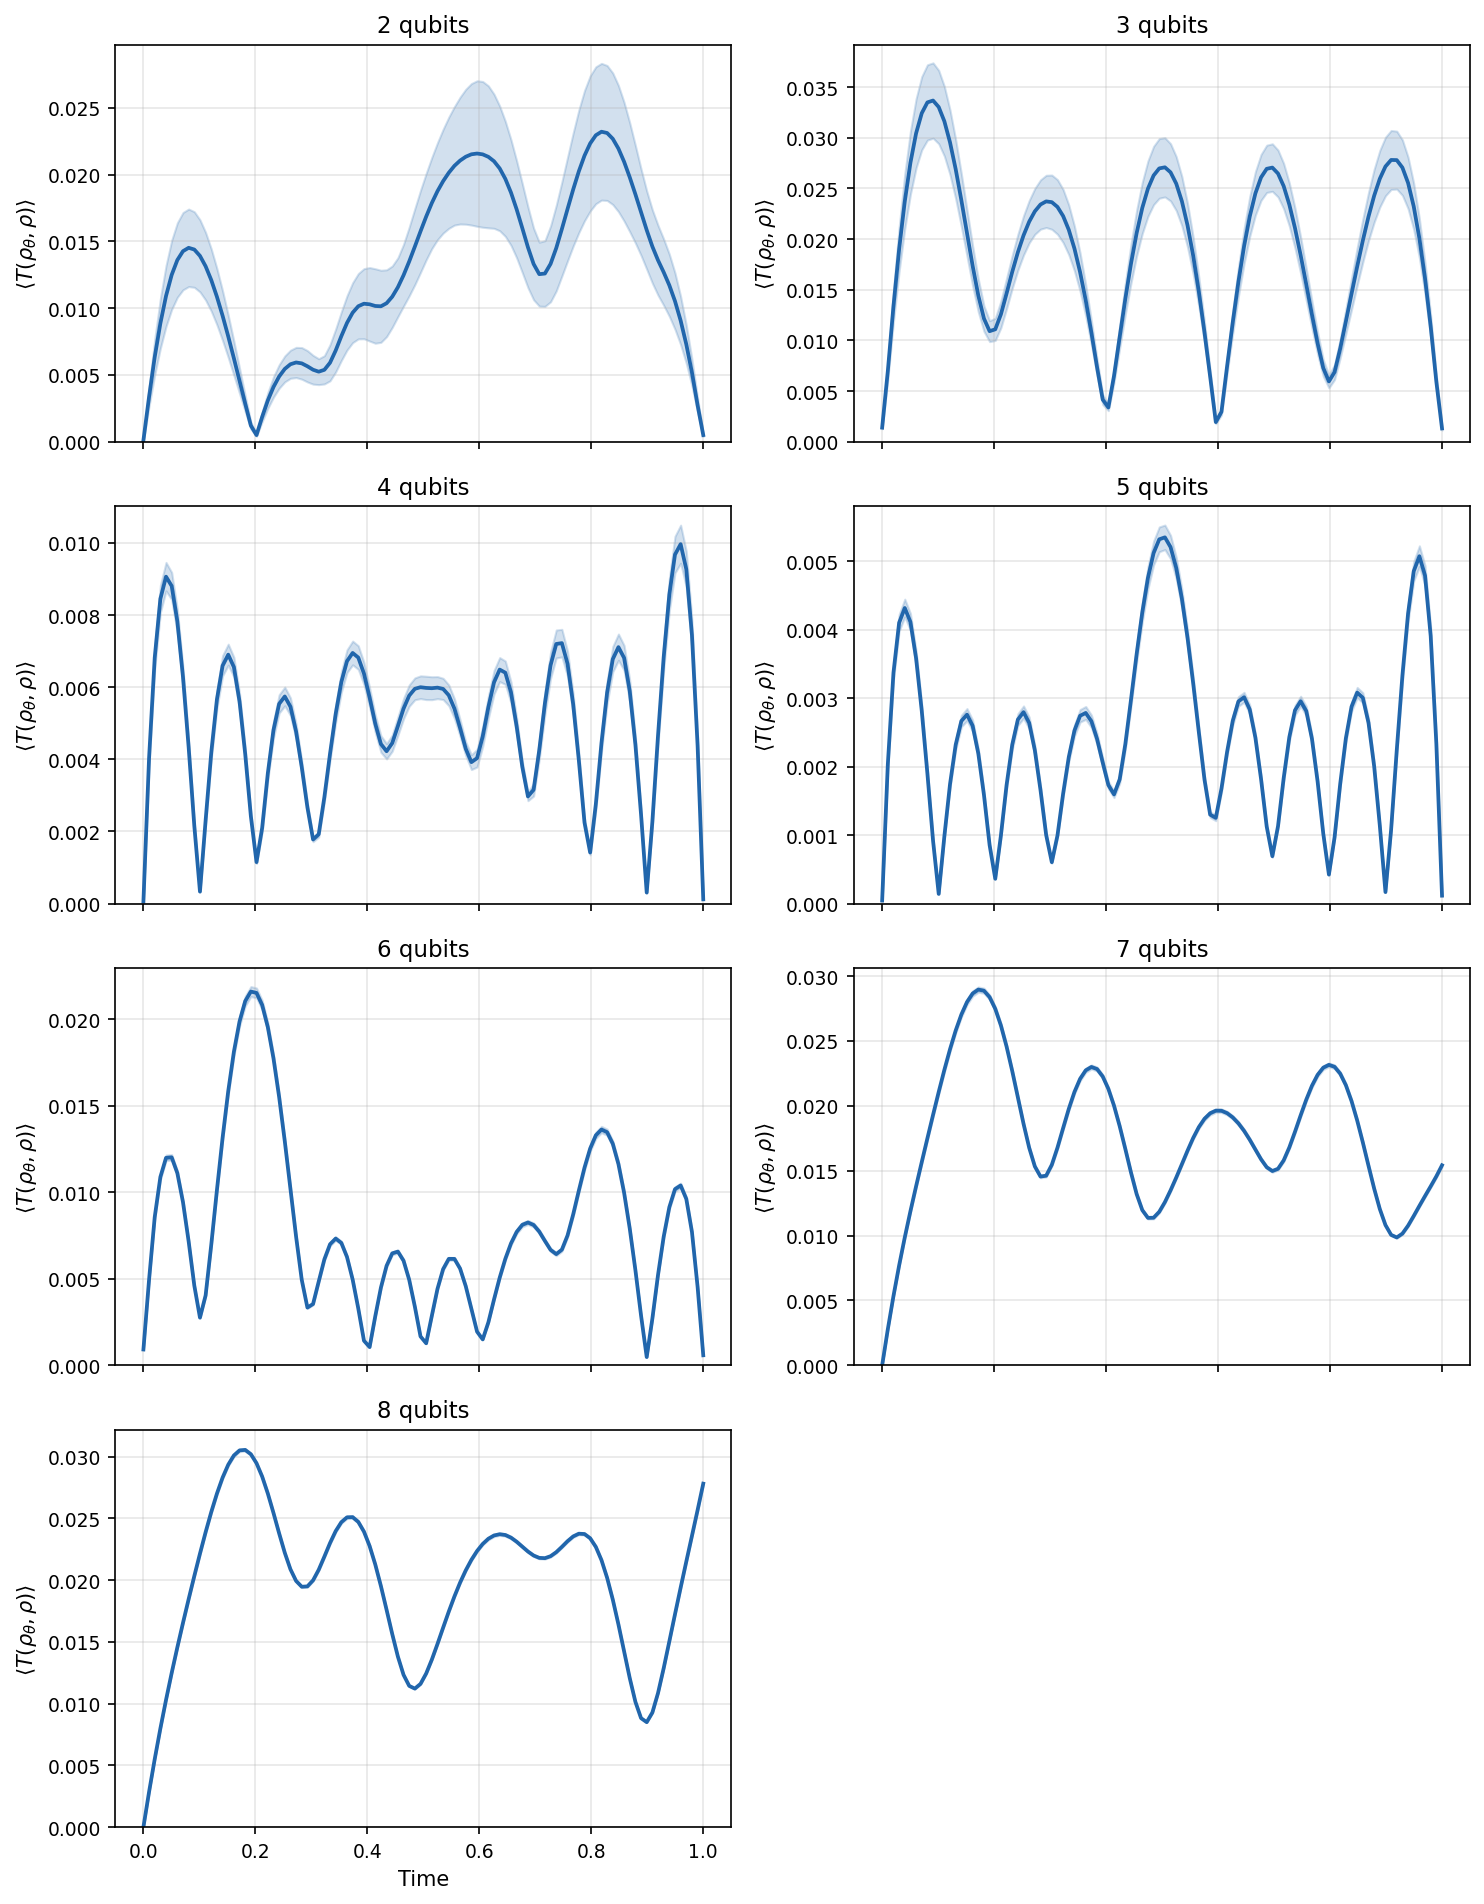

In [4]:
# ── Figure ────────────────────────────────────────────────────────────────────
n_rows = int(np.ceil(len(N_ALL) / 2))
fig, axes = plt.subplots(n_rows, 2,
                         figsize=(10, 3.2 * n_rows),
                         dpi=150, sharex=True)
axes = axes.flatten()

for idx, n in enumerate(N_ALL):
    ax   = axes[idx]
    mean = results[n]["mean"]
    std  = results[n]["std"]

    ax.plot(times, mean, color="#2166ac", lw=1.8)
    ax.fill_between(times,
                    np.clip(mean - std, 0, None),
                    mean + std,
                    color="#2166ac", alpha=0.2)

    ax.set_title(f"{n} qubits", fontsize=11)
    ax.set_ylabel(r"$\langle T(\rho_\theta, \rho) \rangle$", fontsize=10)
    ax.grid(alpha=0.3)
    ax.set_ylim(bottom=0)
    ax.tick_params(labelsize=9)

# x label solo en la última fila
for ax in axes[-2:]:
    ax.set_xlabel("Time", fontsize=10)

# Ocultar panel vacío si N_ALL tiene número impar
if len(N_ALL) % 2 != 0:
    axes[-1].set_visible(False)

plt.tight_layout()
plt.savefig("figures/trace_distance_all_N.pdf", bbox_inches="tight")
plt.show()